<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [3]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [4]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [5]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv('airline_passengers.csv', parse_dates=['month'])

In [6]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df.set_index('month', inplace=True)
df = df.resample('MS').mean()
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[us]', name='month', length=144, freq='MS')

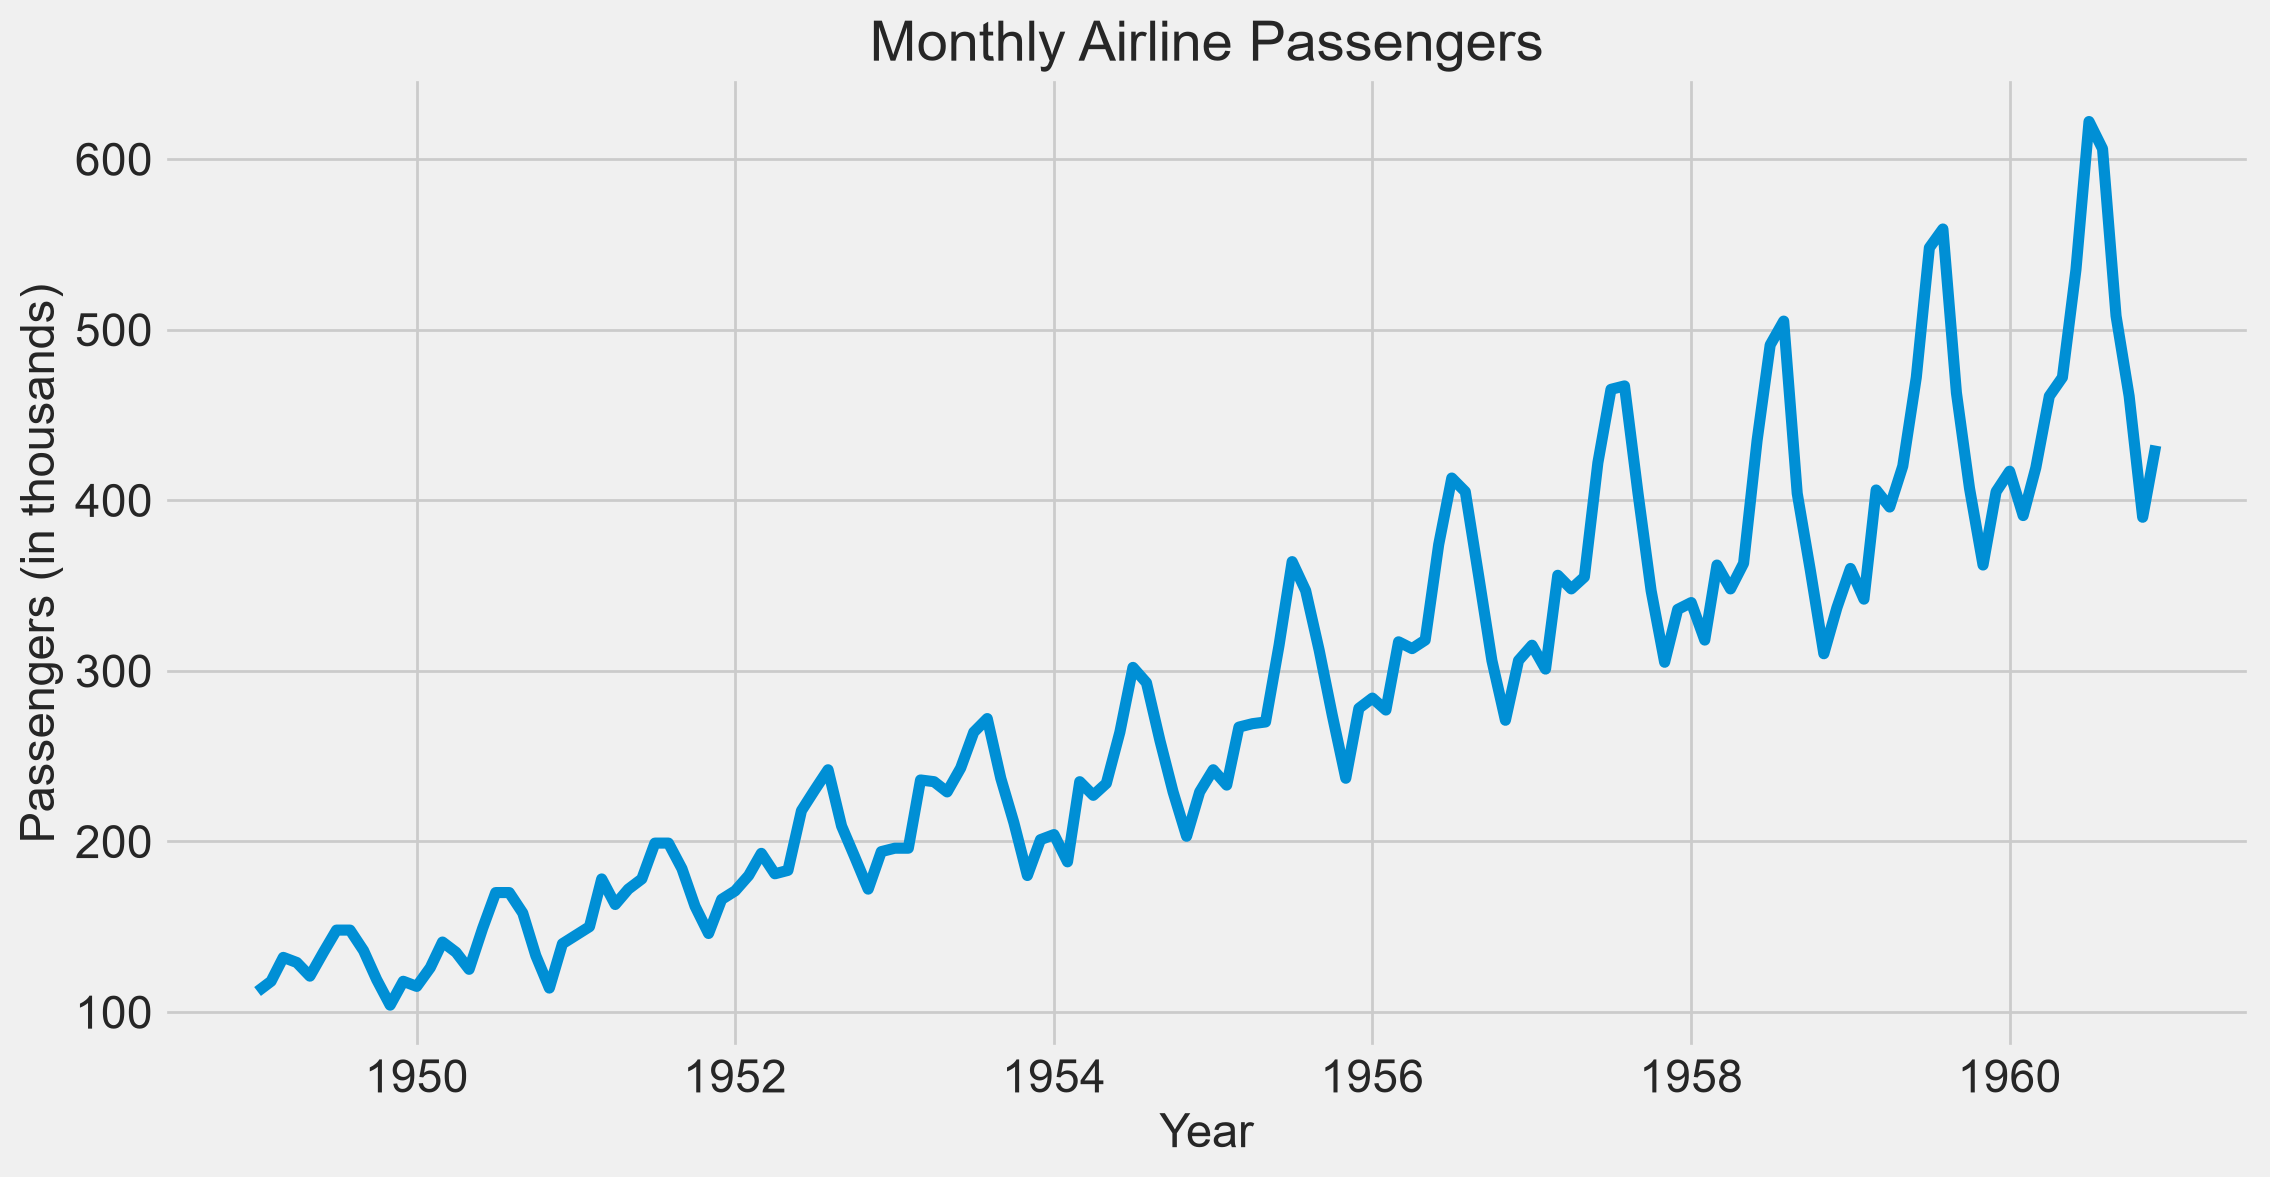

(144, 1)


In [7]:
# 1c. Plot the full series and look at shape.
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['thousands_of_passengers'])
plt.title('Monthly Airline Passengers')
plt.xlabel('Year')
plt.ylabel('Passengers (in thousands)')
plt.show()

# Look at the shape of the dataframe
print(df.shape)

---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [8]:
# Run adf_test on the passenger series. Is it stationary? p value > 0.05 so non-stationary
adf_test(df['thousands_of_passengers'])

Augmented Dickey-Fuller Test: 
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [9]:
# Difference once and re-test
adf_test(df['thousands_of_passengers'].diff(), title='1 Difference')

Augmented Dickey-Fuller Test: 1 Difference
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [10]:
# If needed, difference a second time and re-test
adf_test(df['thousands_of_passengers'].diff().diff(), title='2 Difference')

Augmented Dickey-Fuller Test: 2 Difference
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = 2` 

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

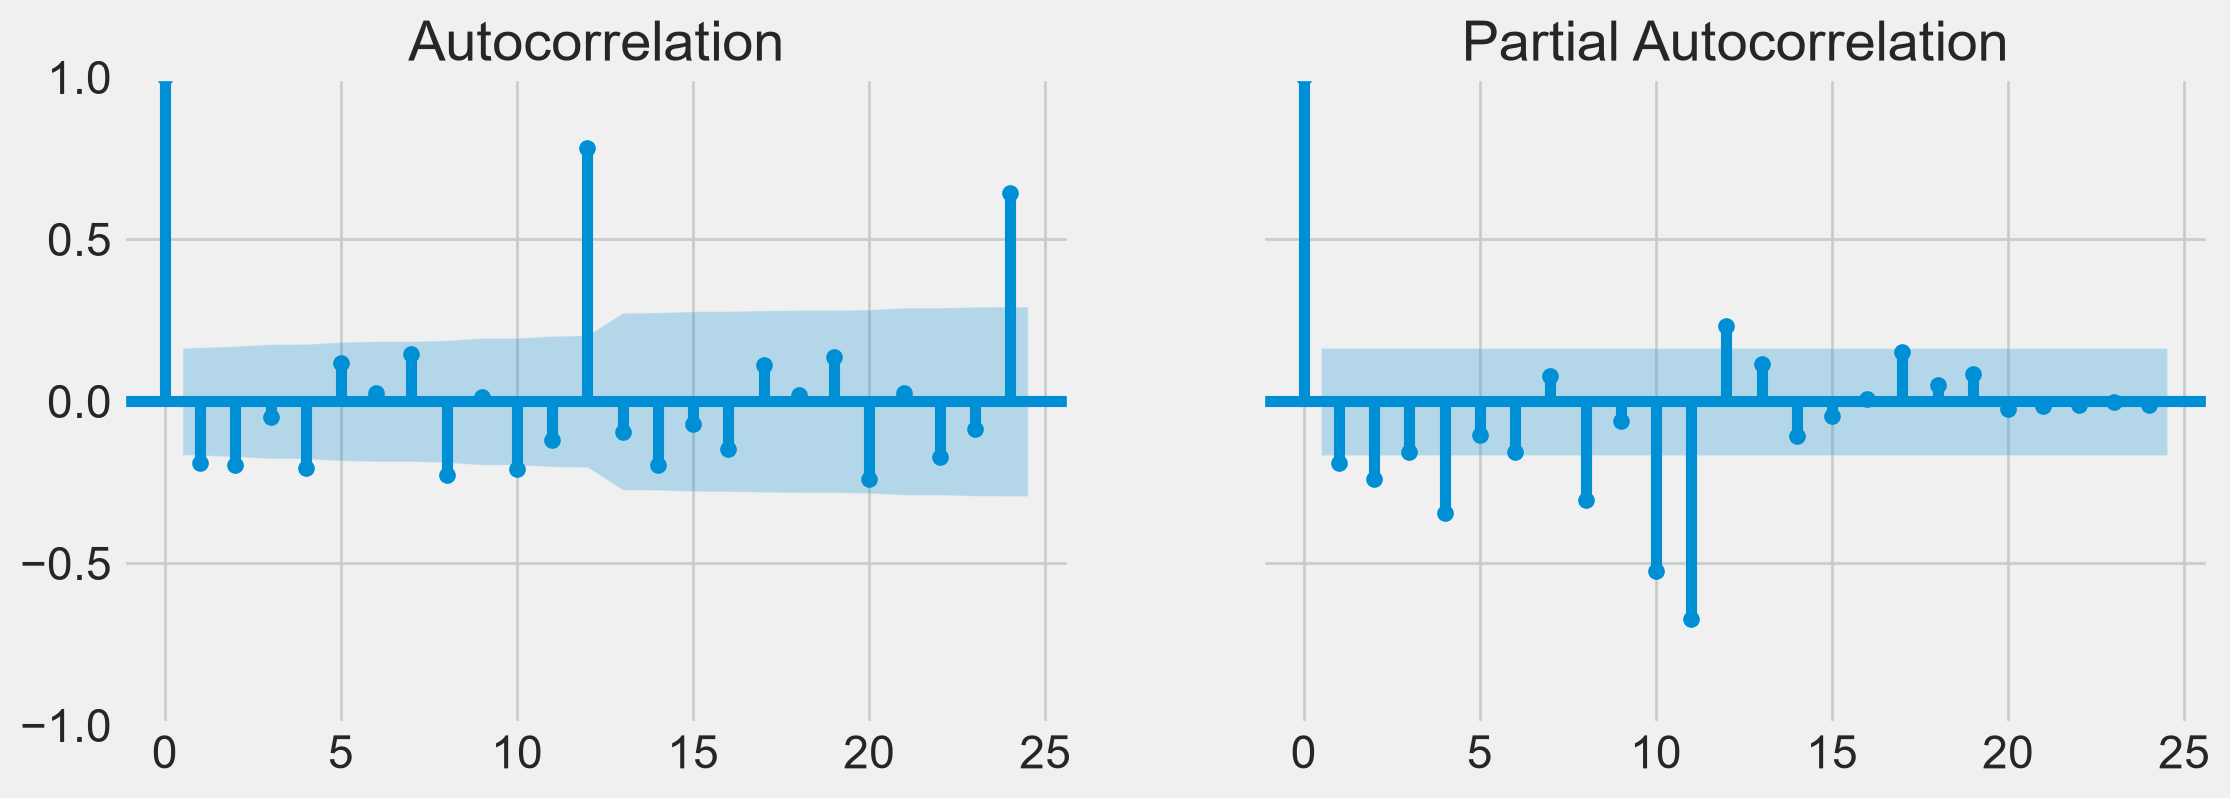

In [11]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df['thousands_of_passengers'].diff().diff().dropna(), lags=24)

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): 0
- q (MA terms): 1

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [25]:
# Run auto_arima with seasonal=False and print the summary
auto_model = auto_arima(df['thousands_of_passengers'], seasonal=False,trace=True)
auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(4, 1, 3)   Log Likelihood                -674.913
Date:                Tue, 18 Aug 2026   AIC                           1365.825
Time:                        11:03:50   BIC                           1389.528
Sample:                    01-01-1949   HQIC                          1375.457
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5582      0.117     -4.782      0.000      -0.787      -0.329
ar.L2          0.4935      0.113      4.375      0.000       0.272       0.715
ar.L3          0.1238      0.128      0.970      0.332      -0.126       0.374
ar.L4         -0.5213      0.085     -6.136      0.000      -0.688      -0.355
ma.L1          0.9069      0.094      9.657      0.000       0.723       1.091
ma.L2         -0.5590      0.145     -3.866      0.000      -0.842      -0.276
ma.L3         -0.7385      0.109     -6.778      0.000      -0.952      -0.525
sigma2       724.1727     85.616      8.458      0.000     556.369     891.976
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                14.59
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [15]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]
df_train.shape , df_test.shape

((132, 1), (12, 1))

### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [18]:
# Fit ARIMA(p,d,q) on the training set
ar_model = ARIMA(df_train['thousands_of_passengers'],order=(4, 1, 3))
ar_results = ar_model.fit()
ar_results.summary()

C:\Users\Qaem\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Qaem\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(4, 1, 3)   Log Likelihood                -607.206
Date:                     Tue, 18 Aug 2026   AIC                           1230.412
Time:                             10:49:21   BIC                           1253.414
Sample:                         01-01-1949   HQIC                          1239.759
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5693      0.115     -4.968      0.000      -0.794      -0.345
ar.L2          0.4828      0.123      3.935      0.000       0.242       0.723
ar.L3          0.1164      0.128      0.911      0.362      -0.134       0.367
ar.L4         -0.5331      0.084     -6.378      0.000      -0.697      -0.369
ma.L1          0.9304      0.103      8.994      0.000       0.728       1.133
ma.L2         -0.5541      0.151     -3.670      0.000      -0.850      -0.258
ma.L3         -0.7290      0.102     -7.155      0.000      -0.929      -0.529
sigma2       607.4737     76.263      7.965      0.000     458.000     756.947
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                11.03
Prob(Q):                              0.65   Prob(JB):                         0.00
Heteroskedasticity (H):               4.40   Skew:                             0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A7. Predict on the test set

In [19]:
# Predict over the test period
ar_pred = ar_results.forecast(steps = len(df_test))
ar_pred.index = df_test.index

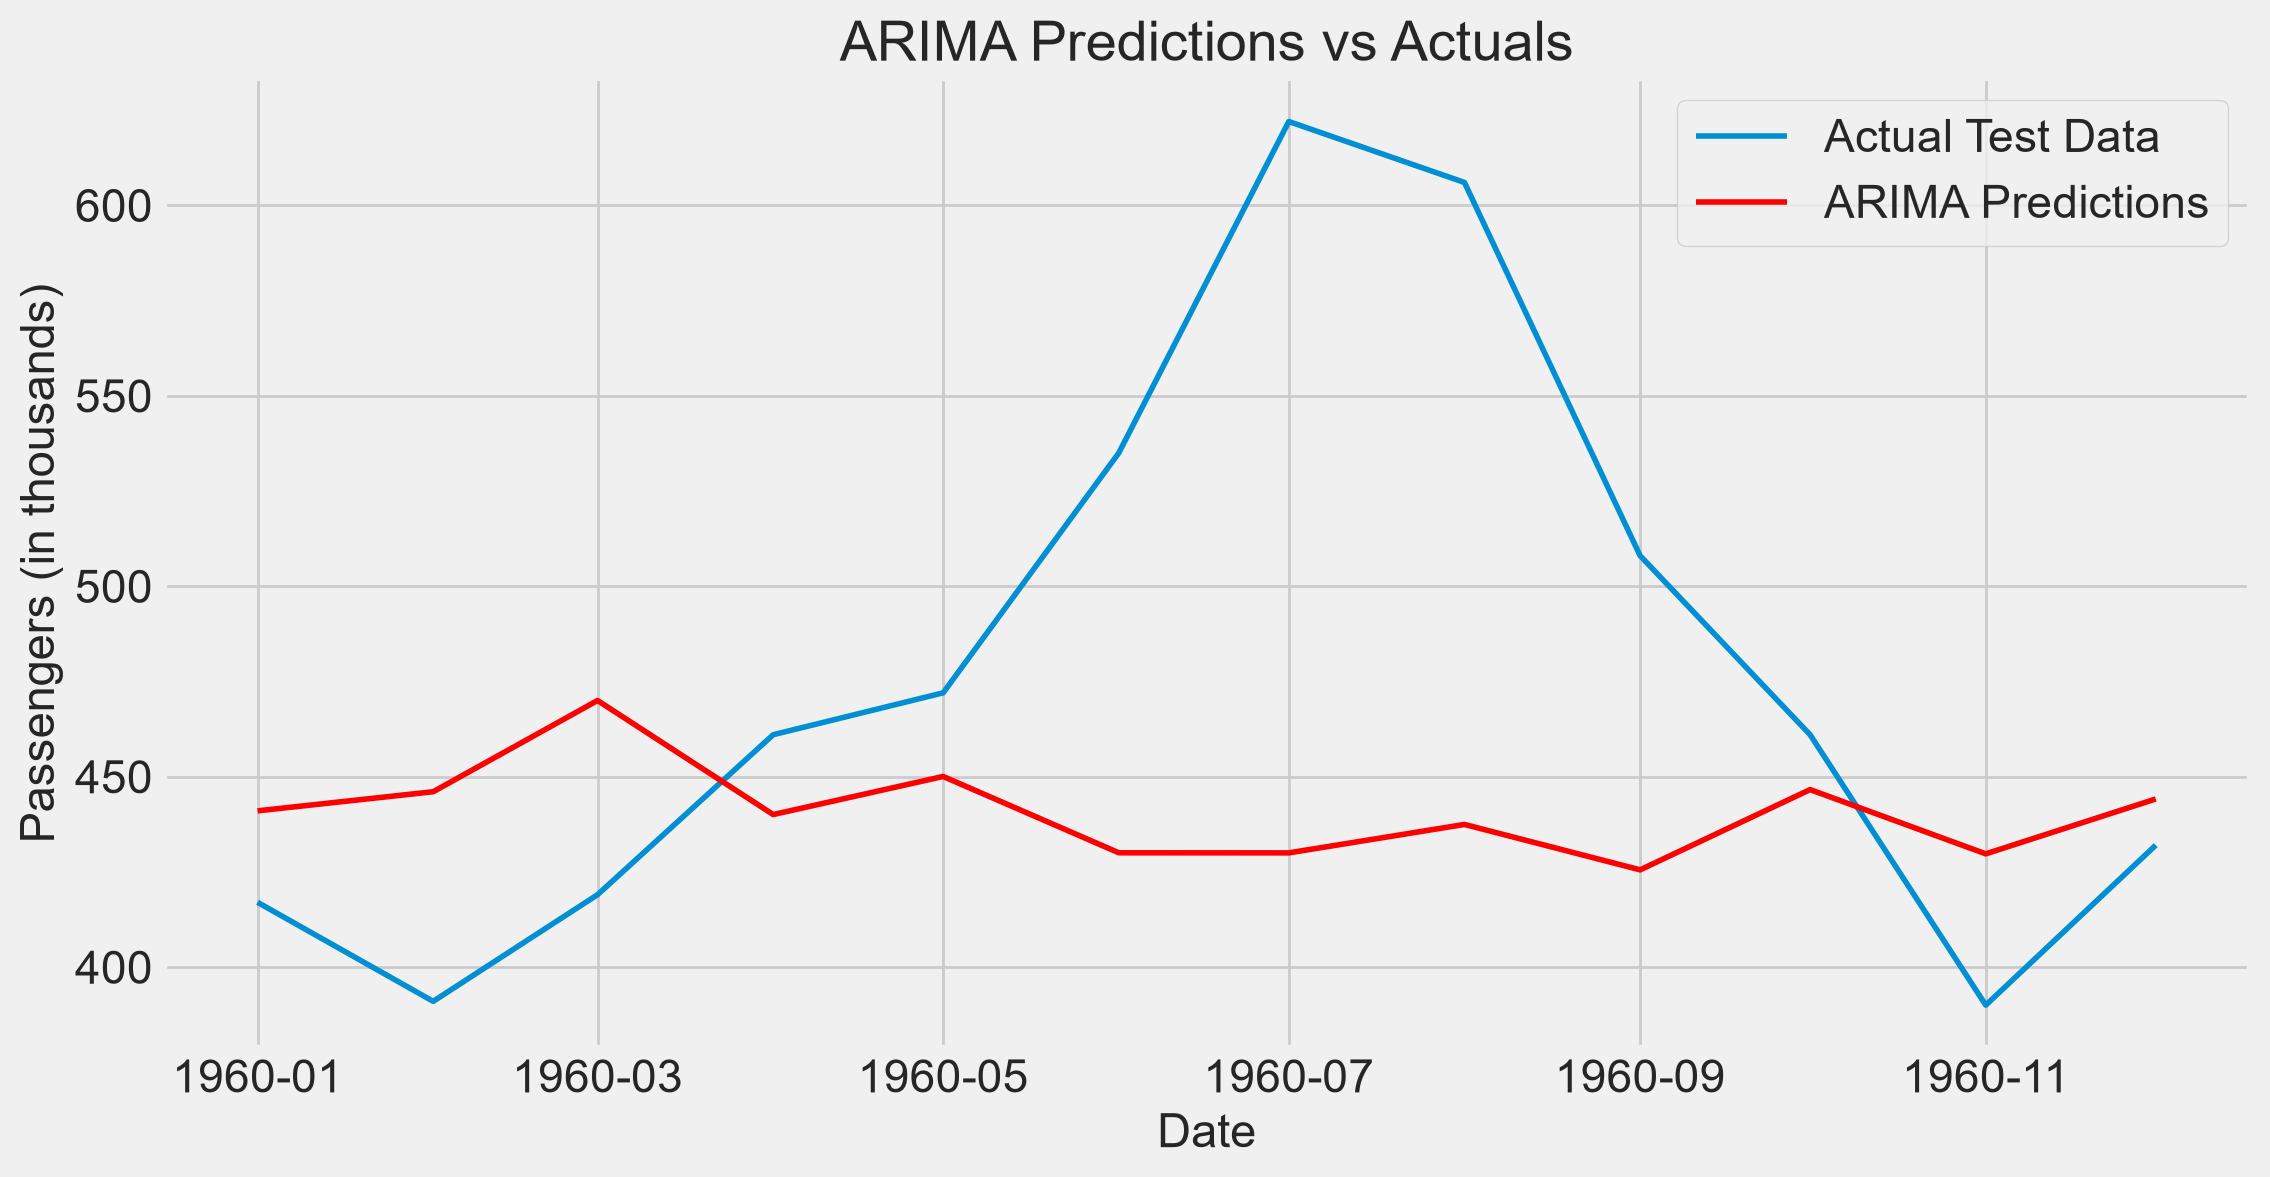

In [28]:
# Plot the test data vs predictions
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual Test Data', linewidth=2)
plt.plot(df_test.index, ar_pred, color='red', label='ARIMA Predictions', linewidth=2)
plt.title('ARIMA Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Passengers (in thousands)')
plt.legend()
plt.show()

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [21]:
# Compute RMSE
ar_rmse = rmse(df_test['thousands_of_passengers'], ar_pred)
print(f"RMSE if ARIMA model: {ar_rmse:.2f}")
print(f"Mean of the Test Series: {df_test['thousands_of_passengers'].mean():.2f}")

RMSE if ARIMA model: 87.64
Mean of the Test Series: 476.17


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

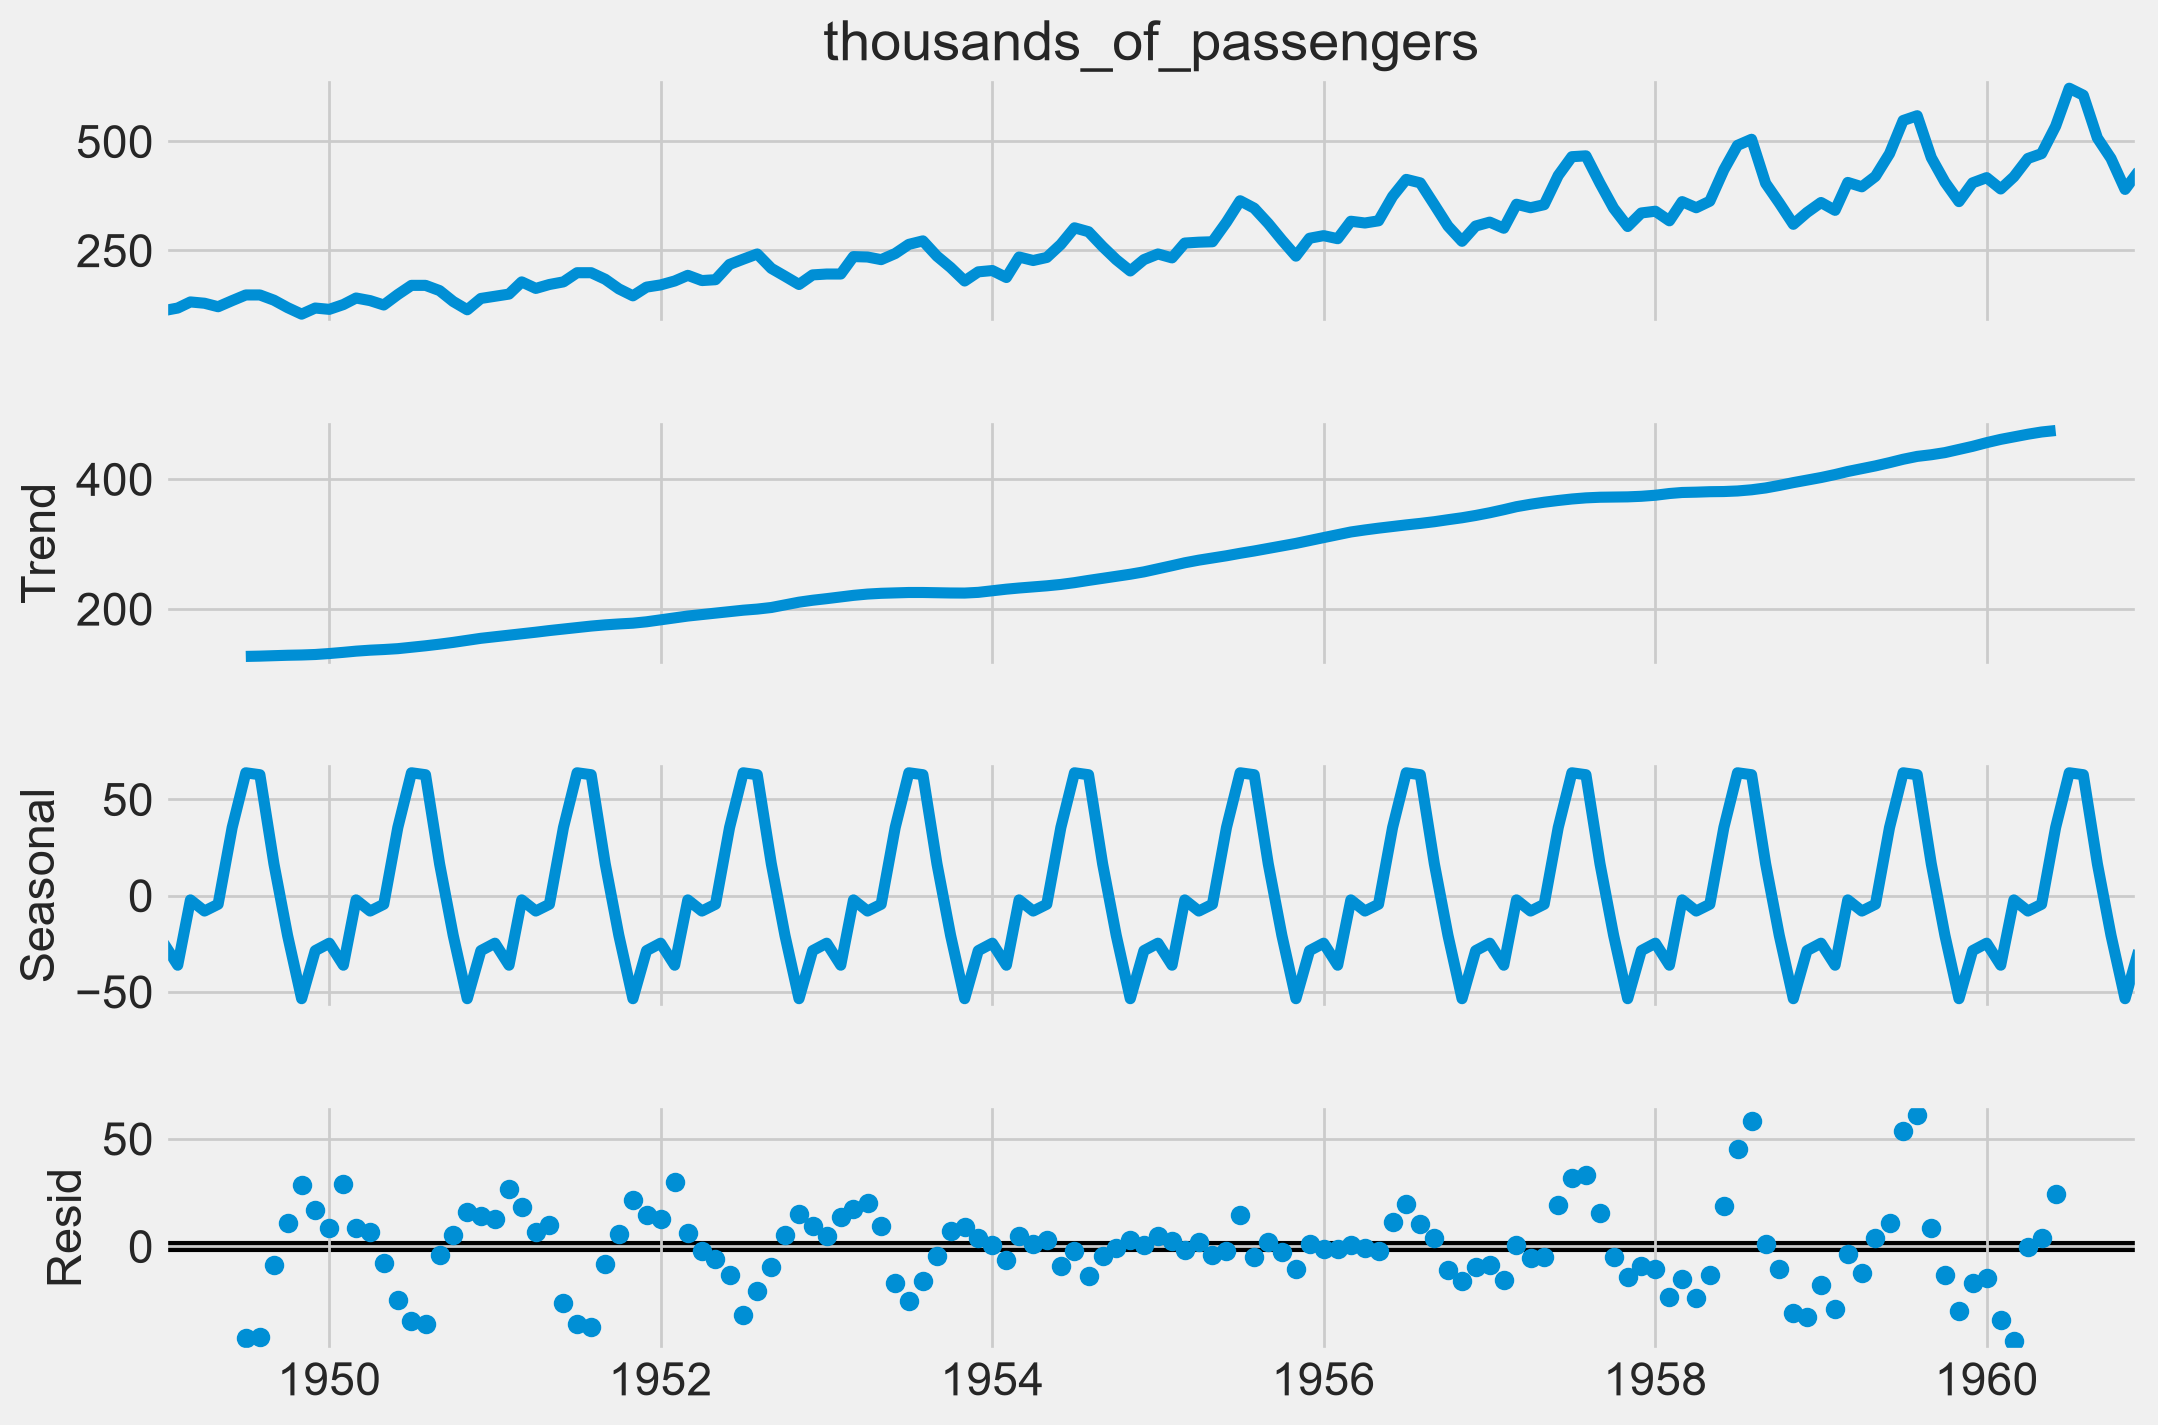

In [22]:
#YOUR CODE HERE
decomp = seasonal_decompose(df['thousands_of_passengers'], period= 12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?

> Yes, there is a very clear, perfectly repeating wave pattern. The period is 12 months (annual seasonality), peaking every summer.

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [29]:
#YOUR CODE HERE
sar_auto = auto_arima(df['thousands_of_passengers'], seasonal=True, m=12, trace = True)
sar_auto.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.82 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.50 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.16 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.46 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.09 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.16 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.42 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.40 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.86 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.06 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.04 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Tue, 18 Aug 2026   AIC                           1017.847
Time:                                     11:09:35   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.602      0.000      -1.057      -0.907
sigma2       129.3128     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [32]:
sar_auto.order

(2, 1, 1)

In [31]:
sar_auto.seasonal_order

(0, 1, 0, 12)

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = (2, 1, 1)
- seasonal_order (P,D,Q,m) = (0, 1, 0, 12)

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [34]:
#YOUR CODE HERE
sar_model = SARIMAX(df_train['thousands_of_passengers'], 
                       order=(2, 1, 1),             # Replace with your (p,d,q)
                       seasonal_order=(0, 1, 0, 12)) # Replace with your (P,D,Q,m)

sar_results = sar_model.fit()
sar_results.summary()

C:\Users\Qaem\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Qaem\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -447.483
Date:                             Tue, 18 Aug 2026   AIC                            902.967
Time:                                     11:15:30   BIC                            914.083
Sample:                                 01-01-1949   HQIC                           907.481
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5253      0.929     -0.566      0.572      -2.345       1.295
ar.L2          0.0110      0.275      0.040      0.968      -0.529       0.551
ma.L1          0.3064      0.935      0.328      0.743      -1.527       2.140
sigma2       108.0093     13.498      8.002      0.000      81.553     134.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.97   Prob(JB):                         0.50
Heteroskedasticity (H):               1.47   Skew:                            -0.09
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

In [37]:
#YOUR CODE HERE
#forecast the test
forecast = sar_results.get_forecast(steps=len(df_test))
sar_pred = forecast.predicted_mean
sar_pred.index = df_test.index
conf_int = forecast.conf_int()

sar_pred


month
1960-01-01    425.135148
1960-02-01    408.815436
1960-03-01    471.901435
1960-04-01    462.399948
1960-05-01    486.128077
1960-06-01    538.276346
1960-07-01    614.195485
1960-08-01    625.239584
1960-09-01    529.215534
1960-10-01    473.228650
1960-11-01    428.221497
1960-12-01    471.225398
Freq: MS, Name: predicted_mean, dtype: float64

### B5. Evaluate

In [39]:
# Compute RMSE
sar_rmse = rmse(df_test['thousands_of_passengers'], sar_pred)
print(f"SARIMA RMSE: {sar_rmse:.2f}")

SARIMA RMSE: 24.87


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

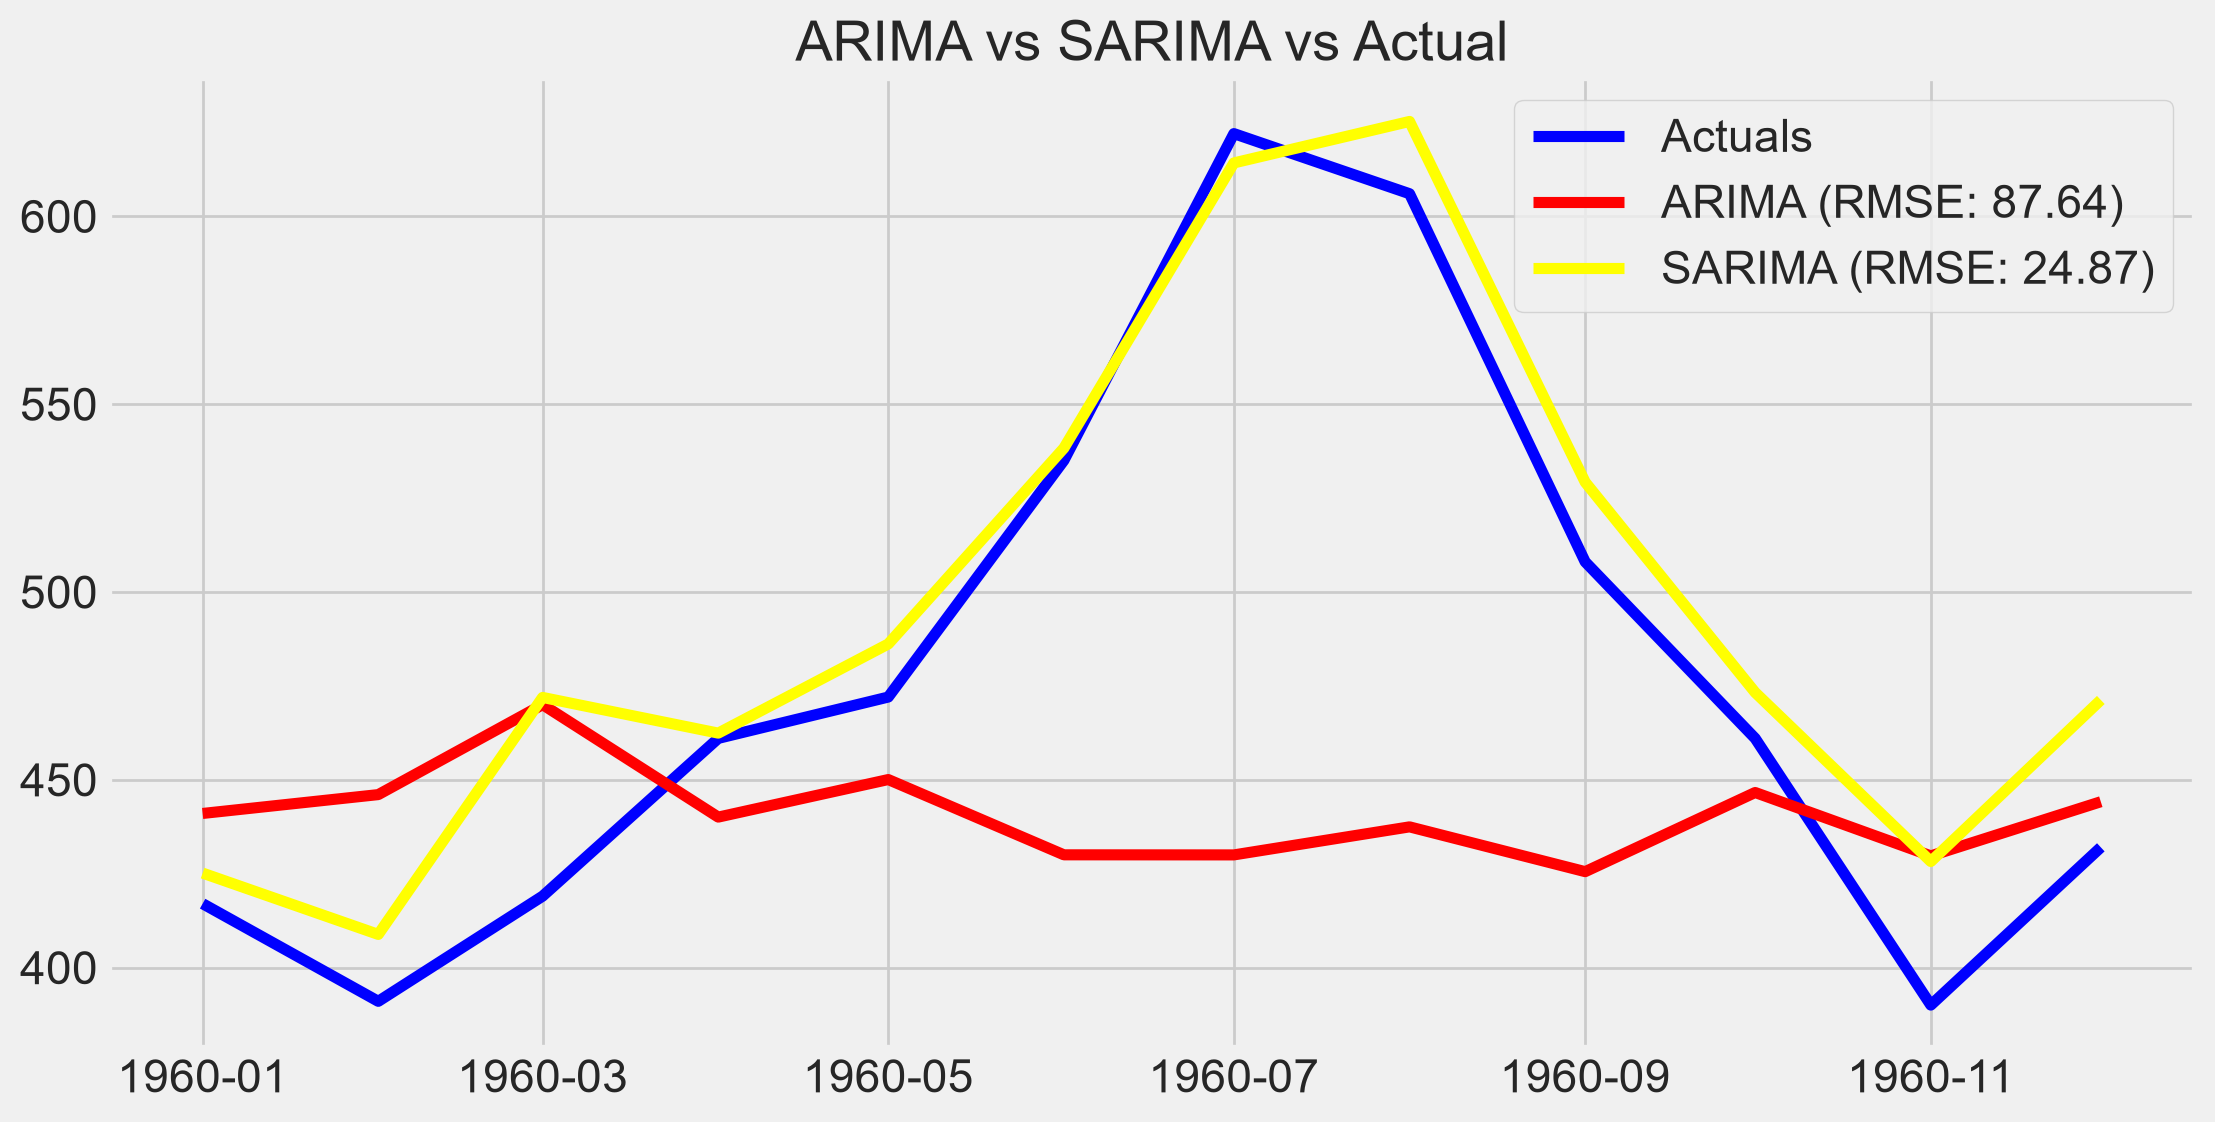

In [43]:
#YOUR CODE HERE

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actuals', color='blue')
plt.plot(df_test.index, ar_pred, label=f'ARIMA (RMSE: {ar_rmse:.2f})', color='red')
plt.plot(df_test.index, sar_pred, label=f'SARIMA (RMSE: {sar_rmse:.2f})', color='yellow')

plt.title('ARIMA vs SARIMA vs Actual')
plt.legend()
plt.show()

# title = 'ARIMA vs SARIMA vs Actual'
# ax = df_test['thousands_of_passengers'].plot(legend=True, figsize=(12, 5), title=title)
# pred_arima.plot(legend=True, ax=ax)
# pred_sarima.plot(legend=True, ax=ax)
# ax.legend(['Actual test data', 'ARIMA predicted', 'SARIMA predicted'])
# plt.show()

<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

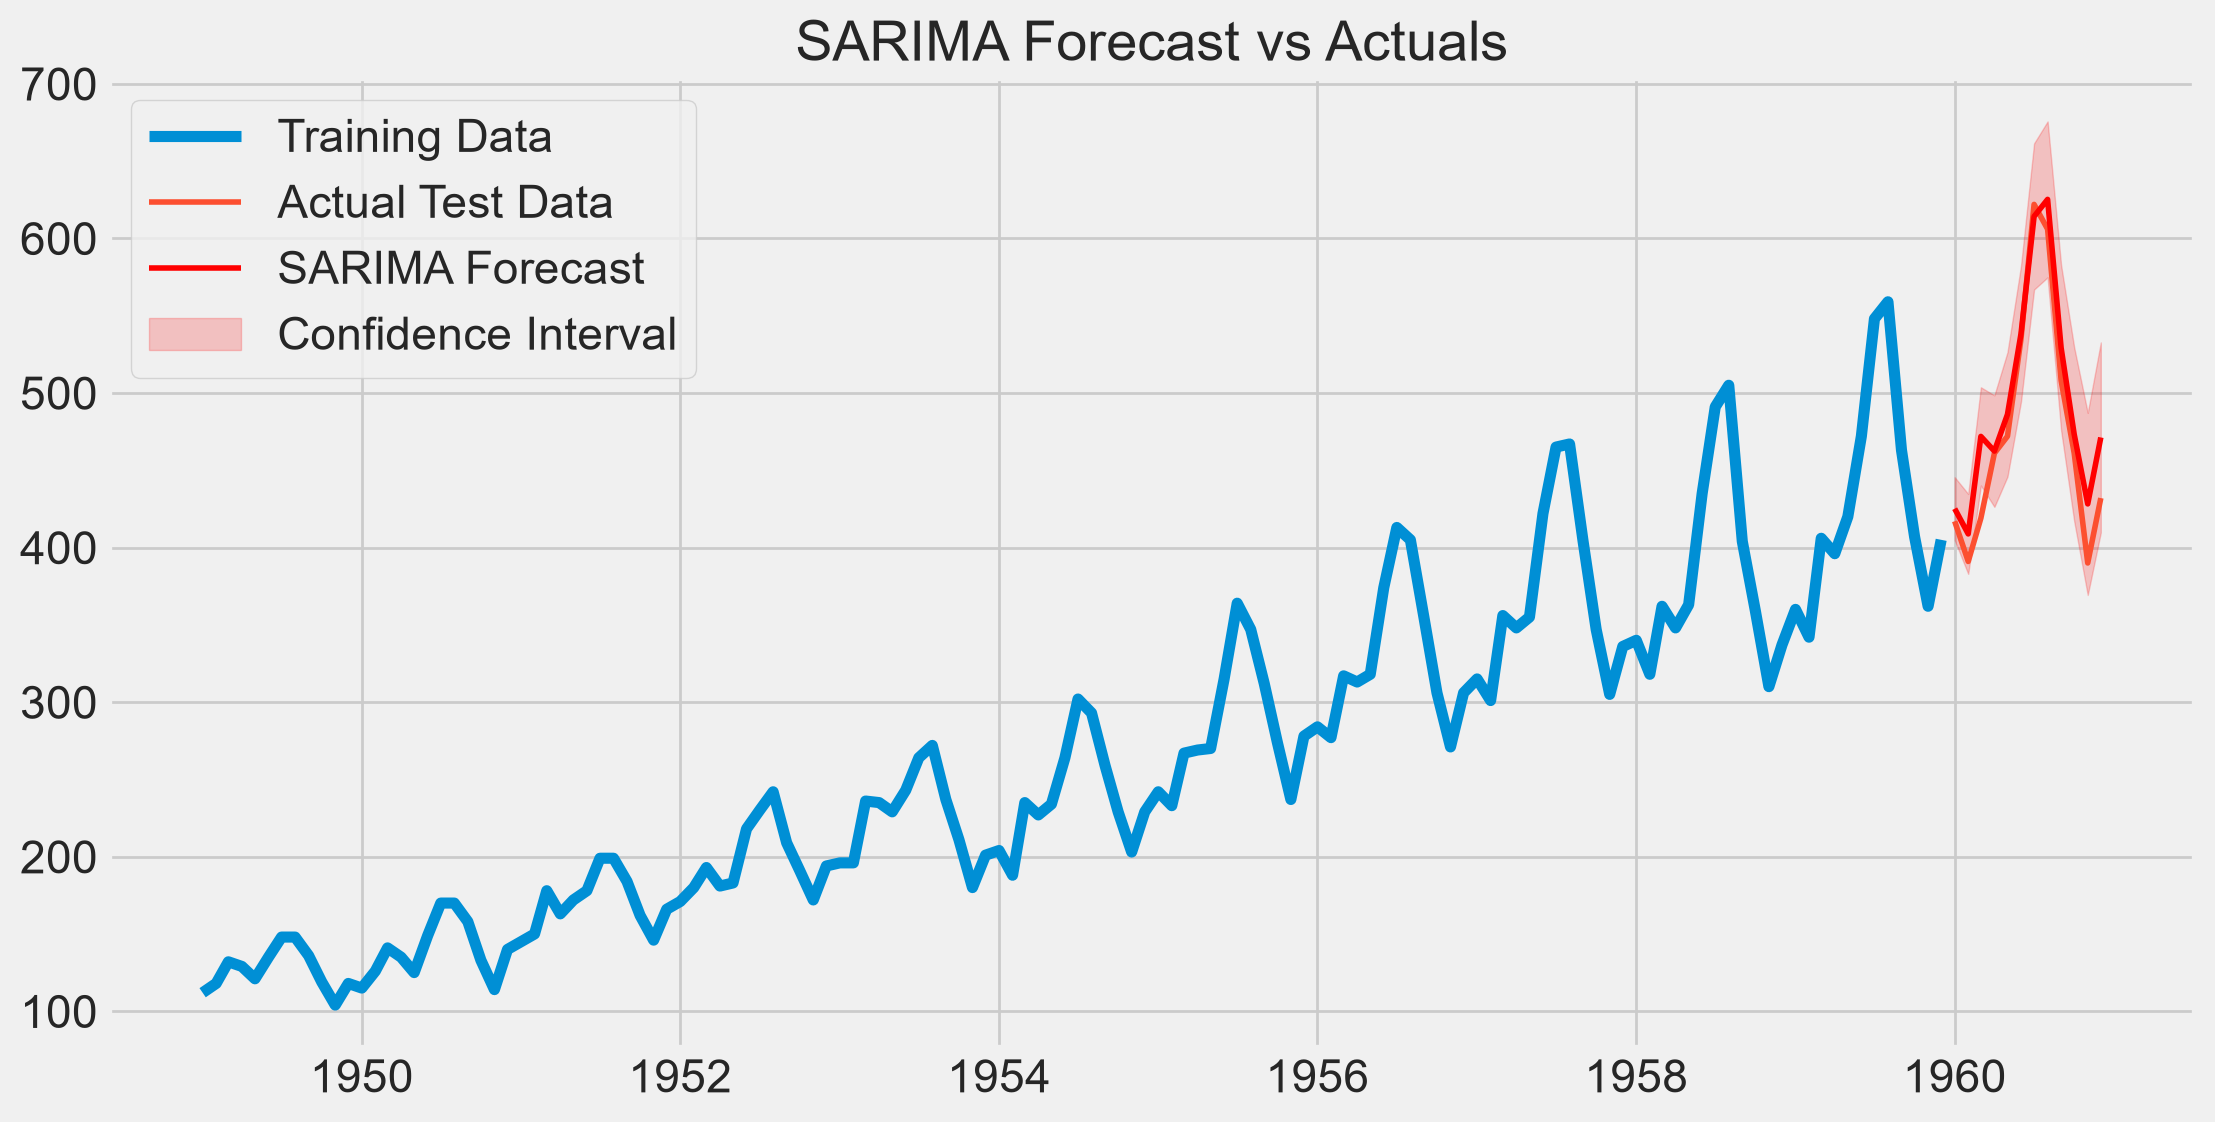

In [38]:
#YOUR CODE HERE
# Plot forecast with confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(df_train.index, df_train['thousands_of_passengers'], label='Training Data')
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual Test Data', linewidth=2)
plt.plot(df_test.index, sar_pred, color='red', label='SARIMA Forecast', linewidth=2)

# Shade the confidence interval
plt.fill_between(df_test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval')

plt.title('SARIMA Forecast vs Actuals')
plt.legend()
plt.show()

## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
